In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import h5py
import figurefirst as fifi

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import h5py

import pynumdiff
from braid_analysis import flymath
from braid_analysis import braid_analysis_plots
from braid_analysis import braid_slicing

from scipy.interpolate import UnivariateSpline

from align_course_direction_analysis import unifying_algo_analysis as uaa

In [4]:
data = 'chrimson'

if data == 'chrimson':
    fname = 'MatchedOrco_chrimson.mat'
    stimname = 'lightstimulus'
    group = 'orcochrim'
elif data == 'acv':
    fname = 'MatchedOrco_acv.mat'
    stimname = 'stimulus'
    group = 'orcoodour'

with h5py.File(fname, 'r') as f:
    print(f.keys())
    data_dict = {}
    print(f[group].keys())
    for key in ['x', 'y', 'time', stimname]:
        refs = f[group][key][:]
        # Flatten the refs array and dereference each element
        data_dict[key] = [f[ref][:].flatten() for ref in refs.flatten()]
    
    df = pd.DataFrame(data_dict)

<KeysViewHDF5 ['#refs#', 'orcochrim']>
<KeysViewHDF5 ['angv', 'angvturn', 'curvature', 'deltamm', 'lightstimulus', 'mode', 'modepre', 'pmove', 'pturn', 'stimulus', 'theta', 'thetafilt', 'time', 'timeline', 'timestamp', 'unfiltcurvature', 'uthetafilt', 'v', 'vmove', 'vx', 'vy', 'vymove', 'windstimulus', 'x', 'xfilt', 'y', 'yfilt']>


In [5]:

df_all = None
wind_direction = np.pi/2 + np.pi



for objid in range(df.shape[0]):
    reset_ix = np.where(np.diff(df['time'][objid])<0)[0]+1
    #for stim_num in range(sum(np.diff(df['stimulus'][objid])>0)):
    stim_num = 0
    for i, ix_start in enumerate(reset_ix[0:-1]):
        stim_num += 1
        
        ix_end = reset_ix[i+1]

        x = df['x'][objid][ix_start:ix_end]/1000.
        y = df['y'][objid][ix_start:ix_end]/1000.
        stimulus = df[stimname][objid][ix_start:ix_end]
        time = df['time'][objid][ix_start:ix_end]
        
        ix_flash = np.where(np.diff(stimulus)>0)[0]

        if len(time) != len(x):
            continue
        if len(time) == 0:
            continue

        interp_timestamps_sec = np.arange(0, np.max(time), 0.02)

        spline_x = UnivariateSpline(time, x, s=1e-4, k=5)  # s=smoothing amount
        interp_x = spline_x(interp_timestamps_sec)
        
        spline_y = UnivariateSpline(time, y, s=1e-4, k=5)  # s=smoothing amount
        interp_y = spline_y(interp_timestamps_sec)

        stimulus_interp = np.interp(interp_timestamps_sec, time, stimulus)

        ix_flash = np.where(np.diff(stimulus_interp)>0.5)[0]

        if len(interp_timestamps_sec) == 0:
            continue

        if 1:
            df_raw = pd.DataFrame({'x': interp_x,
                                   'y': interp_y,
                                   'timestamps_sec': interp_timestamps_sec,
                                   'stimulus': stimulus_interp,
                                   'time_relative_to_flash': interp_timestamps_sec - interp_timestamps_sec[ix_flash],
                                   'obj_id_unique': [objid]*len(interp_x),
                                   'obj_id_unique_event': [str(objid) + '_' + str(stim_num)]*len(interp_x),
                                   })

            dt = np.median(np.diff(df_raw.timestamps_sec.values))
            _, xvel = pynumdiff.savgoldiff(df_raw.x, dt, [2, 3, 3])
            _, yvel = pynumdiff.savgoldiff(df_raw.y, dt, [2, 3, 3])

            df_raw['xvel'] = xvel
            df_raw['yvel'] = yvel
            df_raw = flymath.assign_course_and_ang_vel_to_dataframe(df_raw)

            df_raw.course_smoothish -= wind_direction + np.pi
            df_raw.course_smoothish = wrap_angle(df_raw.course_smoothish)

            df_raw['speed_xy'] = np.sqrt(df_raw.xvel**2 + df_raw.yvel**2)
            
            if df_all is None:
                df_all = df_raw
            else:
                df_all = pd.concat([df_all, df_raw])

KeyboardInterrupt: 

In [ ]:
obj_ids_okay = []
for obj_id in df_all.obj_id_unique_event.unique():
    trajec = df_all[df_all.obj_id_unique_event==obj_id]
    if trajec.speed_xy.median() > 0.01: #1:
        obj_ids_okay.append(obj_id)

In [ ]:
df_trim = df_all[df_all.obj_id_unique_event.isin(obj_ids_okay)]
trim_name = fname.split('.')[0] + '_trim' + '.parquet'
df_trim.to_parquet(trim_name)

In [7]:
df_trim = pd.read_parquet('MatchedOrco_chrimson_trim.parquet')

In [8]:
if 0:
    for obj_id in df_trim.obj_id_unique_event.unique():
        trajec = df_all[df_all.obj_id_unique_event==obj_id]
        #print(len(trajec))

Text(0, 0.5, 'occurrences')

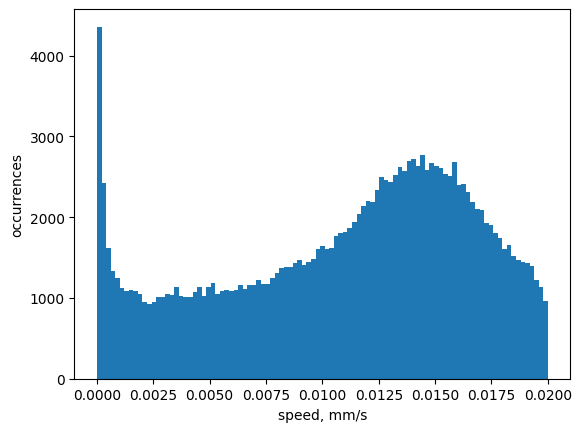

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)

_ = ax.hist(df_trim.speed_xy.values, bins=np.linspace(0, 0.02, 100))
ax.set_xlabel('speed, mm/s')
ax.set_ylabel('occurrences')

(-5.0, 30.0)

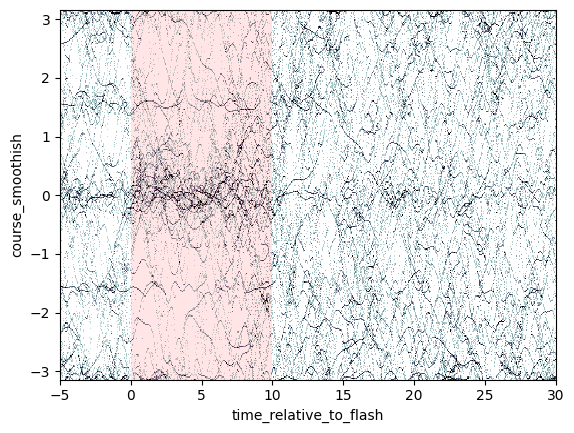

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)


braid_analysis_plots.plot_column_vs_time(df_trim, 
                                         norm_columns_to_min_max=True,
                                         res_y=0.02, res_x=0.05, ax=ax)

ax.fill_betweenx([np.pi, -np.pi], 
                 0,    # flash start
                 10, # flash end
                 color='red', 
                 alpha=0.1, 
                 edgecolor='none',
                 zorder=1000)

ax.set_xlim(-5, 30)

(-5.0, 30.0)

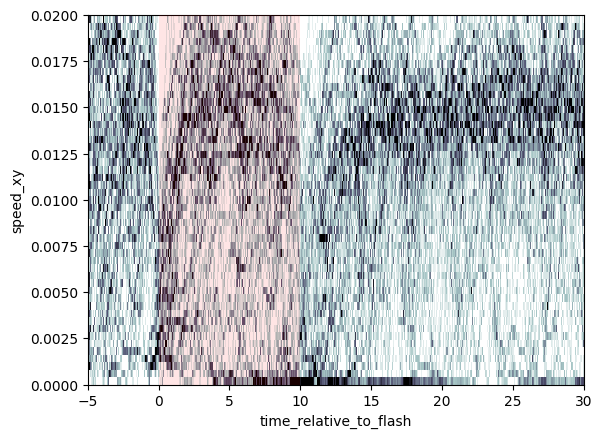

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

bin_y = np.linspace(0, 0.02, 50)


braid_analysis_plots.plot_column_vs_time(df_trim, 
                                         norm_columns_to_min_max=True,
                                         column='speed_xy',
                                         bin_y=bin_y,
                                         res_y=0.01, res_x=0.06, ax=ax)

ax.fill_betweenx([np.pi, -np.pi], 
                 0,    # flash start
                 10, # flash end
                 color='red', 
                 alpha=0.1, 
                 edgecolor='none',
                 zorder=1000)

ax.set_xlim(-5, 30)

In [13]:
len(df_all.obj_id_unique_event.unique())

74

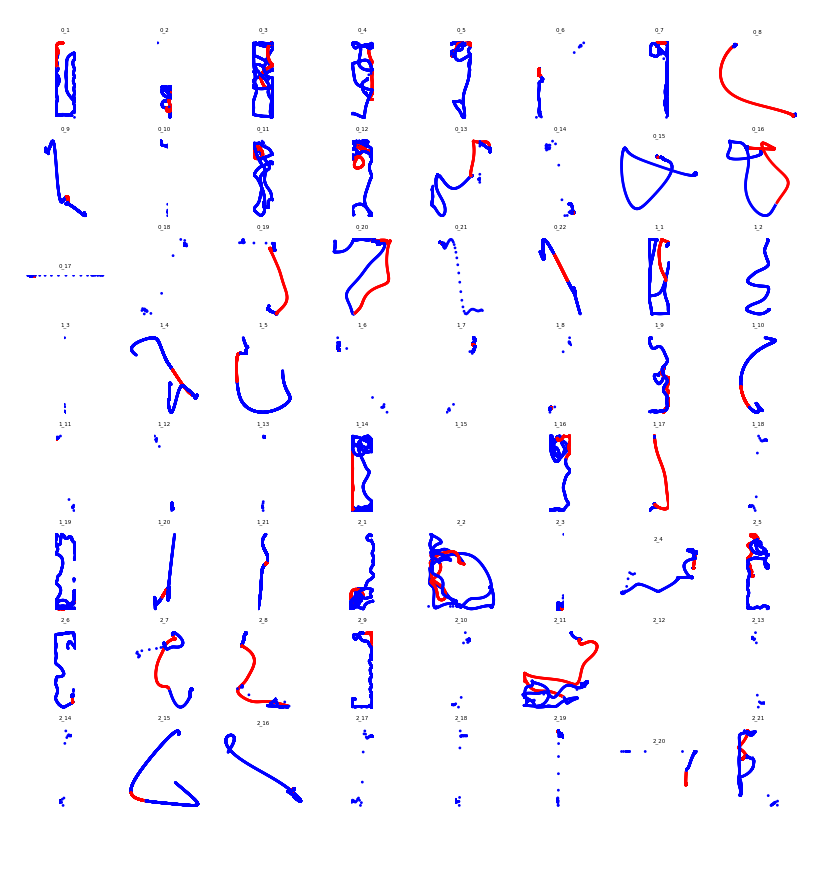

In [20]:
fig = plt.figure( figsize=(10,10) )
for i in range(64):
    ax = fig.add_subplot(8,8,i+1)

    objid = df_all.obj_id_unique_event.unique()[i]
    trajec = df_all[df_all.obj_id_unique_event==objid]
    ax.scatter(trajec.x,
                trajec.y, 
                c=trajec.stimulus, cmap='bwr',
                s=1)
    
    ax.set_aspect('equal')
    fifi.mpl_functions.adjust_spines(ax, [])
    ax.set_title(objid)
    fifi.mpl_functions.set_fontsize(ax, 4)

In [34]:
trajec = df_all[df_all.obj_id_unique_event=='0_4']

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(trajec.x,
                trajec.y, 
                c=trajec.stimulus, cmap='bwr',
                s=1)


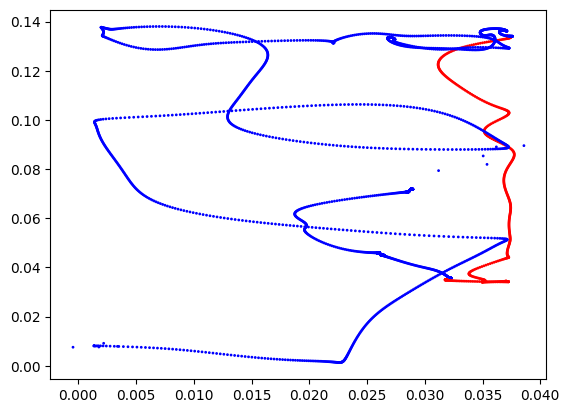

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(trajec.x,
                trajec.y, 
                c=trajec.stimulus, cmap='bwr',
                s=1)


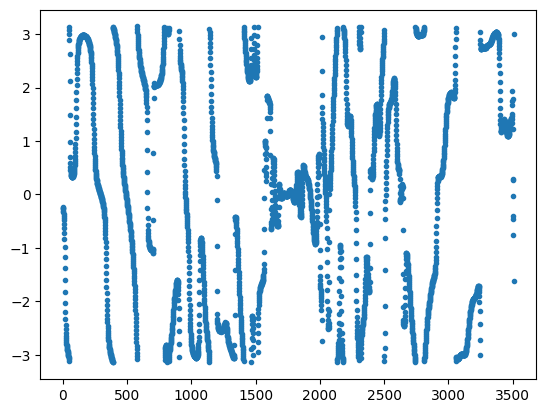

In [36]:
plt.plot(trajec.course_smoothish, '.')

In [37]:
trajec.to_parquet('../../../../../Data/Animal_Trajectory_Data/walking_drosophila/walking_fly_0_4.parquet')

In [323]:
trajec = df_all[df_all.obj_id_unique_event=='11_7']

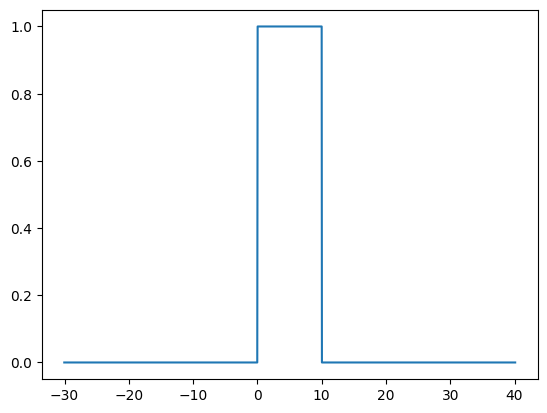

In [324]:
plt.plot(trajec.time_relative_to_flash, trajec.stimulus)

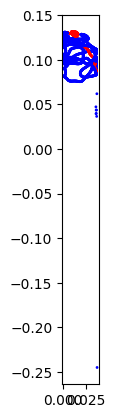

In [325]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(trajec.x,
            trajec.y, 
            c=trajec.stimulus, cmap='bwr',
            s=1)

ax.set_aspect('equal')

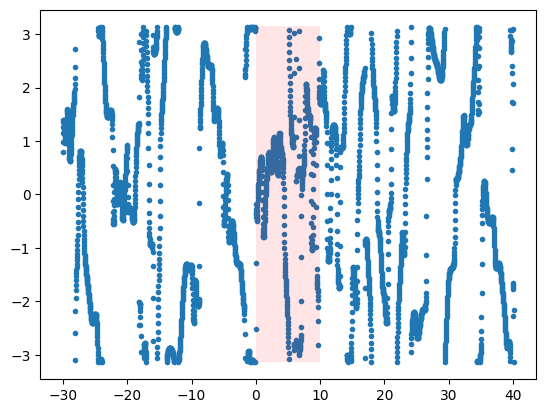

In [251]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(trajec.time_relative_to_flash, trajec.course_smoothish, '.')


ax.fill_betweenx([np.pi, -np.pi], 
                 0,    # flash start
                 10, # flash end
                 color='red', 
                 alpha=0.1, 
                 edgecolor='none',
                 zorder=1000)

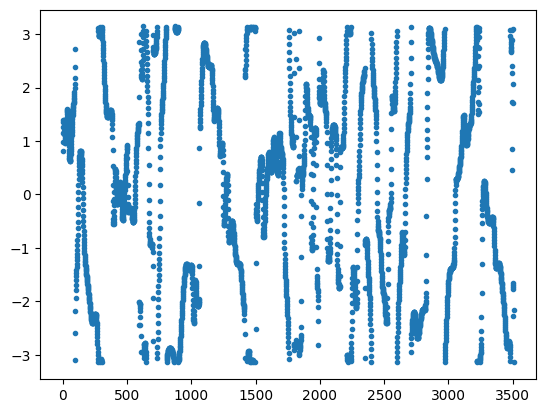

In [252]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(trajec.course_smoothish, '.')

In [253]:
course = trajec.course_smoothish.values
abs_min_ix = 2000
abs_max_ix = 3000
min_ix_range = 400
max_ix_range = 500

unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = 50, 
                                                  n_bootstraps=2, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0)


Interrupt request received


/home/caveman/PY38/lib/python3.8/site-packages/cvxpy/problems/problem.py:1385: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [259]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [260]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,AM_1_1,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix
1,2129,2546,0.047756,3.819313,1.143756,0.919137,0.224087,0.343319,0.262023,0.262023,0.799905,-0.091666,-0.110258,0.126258,0.038852,0.243802,1.109341,2157
0,2004,2471,0.011951,-4.755938,-2.084603,0.608231,0.055313,0.188880,0.236668,0.236668,0.474664,0.032404,0.201286,0.333894,-0.199106,0.090940,1.428318,2237


In [261]:
#best_unifying_algo_fit = unifying_algo_fit.iloc[1]
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

In [262]:
import figurefirst as fifi

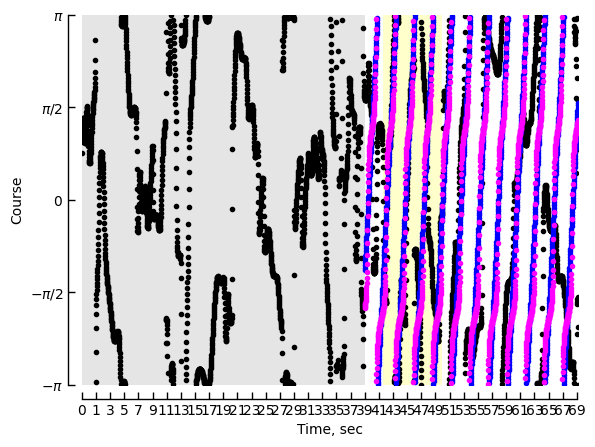

In [263]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(trajec.time_relative_to_flash))
xticklabels = (dt*xticks).astype(int)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [309]:
unifying_algo_fit = pd.read_parquet('unifying_algo_results_MatchedOrco_chrimson_trim.parquet')
df = pd.read_parquet('MatchedOrco_chrimson_trim.parquet')

In [310]:
unifying_algo_fit.obj_id_unique_event.unique()

array(['0_3', '1_14'], dtype=object)

In [311]:
obj_id = '1_14'
unifying_algo_fit = unifying_algo_fit[unifying_algo_fit.obj_id_unique_event==obj_id]

In [312]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [313]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,AM_1_1,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix,iteration,obj_id_unique_event
0,2586,2988,0.024270,-3.188124,-3.093076,0.945899,0.896425,0.945782,0.002397,0.002397,0.896541,0.106027,-0.015562,0.920882,0.031100,0.947697,0.388833,2721,0,1_14
8,2553,2975,0.024379,-3.339767,-3.105124,0.984066,0.853556,0.983893,0.004755,0.004755,0.853730,0.071814,-0.042617,0.931151,-0.100699,0.867377,0.398654,2715,8,1_14
6,2520,2965,0.021385,-1.569547,2.830281,1.055413,0.728046,1.024698,-0.095455,-0.095455,0.758761,0.083812,-0.168303,0.949105,0.104523,0.689822,0.456839,2718,6,1_14
1,2484,2904,0.022358,2.084125,2.691772,1.063951,0.704432,0.995982,-0.140771,-0.140771,0.772400,0.000658,-0.210148,0.847911,0.084199,0.662090,0.479669,2718,1,1_14
2,2523,2994,0.023790,-1.781633,3.044413,0.995605,0.768727,0.993469,-0.021909,-0.021909,0.770862,0.035764,-0.088563,0.956088,0.060155,0.772120,0.484171,2716,2,1_14
7,2508,2958,0.020595,0.771731,2.926440,1.022640,0.718456,1.008775,-0.063445,-0.063445,0.732321,0.048058,-0.153785,0.899174,-0.063171,0.702550,0.485238,2709,7,1_14
3,2504,2952,0.023834,4.291071,2.747367,1.056049,0.662728,0.998024,-0.139484,-0.139484,0.720754,0.024750,-0.212423,0.961585,0.102495,0.627554,0.547665,2720,3,1_14
4,2430,2918,0.022832,0.743072,2.502171,1.016044,0.656351,0.887961,-0.172236,-0.172236,0.784433,-0.056534,-0.213415,0.885491,0.160948,0.645987,0.879319,2445,4,1_14
5,2279,2698,0.011270,-6.329859,-2.981710,1.033095,0.648636,1.023351,0.060426,0.060426,0.658381,0.053226,0.087691,0.847887,0.016006,0.627857,0.917181,2488,5,1_14
9,2327,2747,0.012712,2.602776,-3.117446,1.032701,0.619075,1.032460,0.009984,0.009984,0.619316,-0.024840,-0.000260,0.519362,-0.103355,0.599472,0.926523,2537,9,1_14


In [314]:
trajec = df[df.obj_id_unique_event==obj_id]
course = trajec.course_smoothish

In [315]:
#best_unifying_algo_fit = unifying_algo_fit.iloc[1]
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

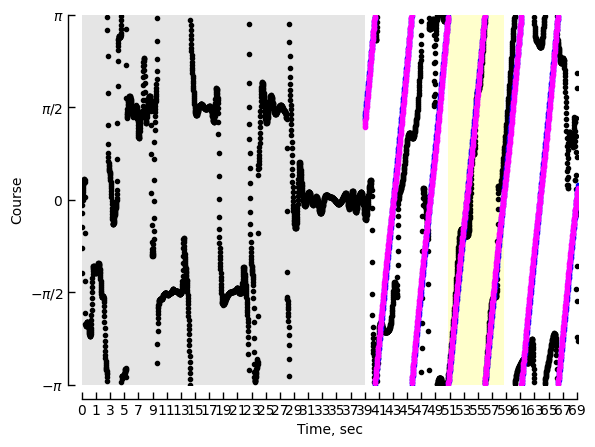

In [316]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(trajec.time_relative_to_flash))
xticklabels = (dt*xticks).astype(int)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [317]:
.02/0.02

1.0

In [318]:
len(df.obj_id_unique_event.unique())

50